In [198]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [199]:
df = pd.read_csv("data/agg_gaze_fix_stats.csv")

In [200]:
df.columns

Index(['presentation', 'n_fixations_sentence1', 'n_fixations_sentence2',
       'horizontal_regressions_sentence1', 'vertical_regressions_sentence1',
       'horizontal_regressions_sentence2', 'vertical_regressions_sentence2',
       'horizontal_regressions_sentence1_after_sentence2',
       'vertical_regressions_sentence1_after_sentence2',
       'cross_sentence_regressions', 'gaze_samples_sentence1_after_sentence2',
       'real_index', 'participant', 'participant_id', 'Uncertainty',
       'Resolution', 'Unc Valence', 'Res Valence'],
      dtype='str')

In [201]:
# EXCLUDED_PARTICIPANTS = ["3", "11", "7", "6"]

# n_before_exclusion = df["participant_id"].nunique()
# df = df[~df["participant_id"].astype(str).isin([str(p) for p in EXCLUDED_PARTICIPANTS])].reset_index(drop=True)
# n_after_exclusion = df["participant_id"].nunique()

# print(f"Excluded participants: {EXCLUDED_PARTICIPANTS}")
# print(f"Participants: {n_before_exclusion} -> {n_after_exclusion} "
#       f"({n_before_exclusion - n_after_exclusion} dropped)")
# print(f"Rows remaining after participant exclusion: {len(df)}")

# Principal Component Analysis

In [202]:
ID_COLS = ["participant", "participant_id", "real_index", "presentation"]
 
# The four condition/factor columns (your experimental design variables)
CONDITION_COLS = ["Uncertainty", "Resolution", "Unc Valence", "Res Valence"]
 
FEATURE_COLS = [
    "n_fixations_sentence1",
    "n_fixations_sentence2",
    "horizontal_regressions_sentence1",
    "horizontal_regressions_sentence2",
    "horizontal_regressions_sentence1_after_sentence2",
    "cross_sentence_regressions",
    "gaze_samples_sentence1_after_sentence2",
]

In [203]:
df_clean = df.dropna(subset=FEATURE_COLS).reset_index(drop=True)
 
ALL_ID_COLS = ID_COLS + CONDITION_COLS
 
X = df_clean[FEATURE_COLS].values

In [204]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [205]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
 
explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)
 
print("Explained variance ratio per component:")
for i, (v, c) in enumerate(zip(explained_var, cum_var), start=1):
    print(f"  PC{i}: {v:.3f}  (cumulative: {c:.3f})")

Explained variance ratio per component:
  PC1: 0.467  (cumulative: 0.467)
  PC2: 0.194  (cumulative: 0.661)
  PC3: 0.137  (cumulative: 0.798)
  PC4: 0.088  (cumulative: 0.887)
  PC5: 0.066  (cumulative: 0.952)
  PC6: 0.031  (cumulative: 0.984)
  PC7: 0.016  (cumulative: 1.000)


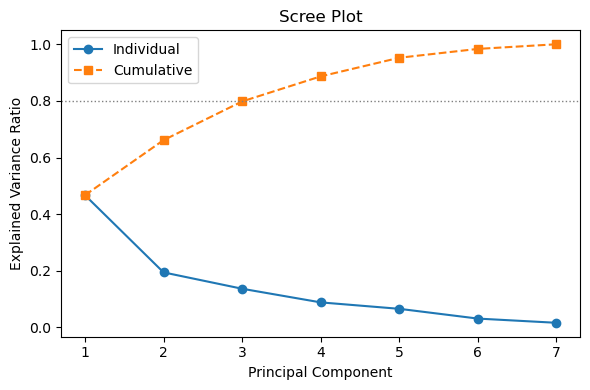

In [206]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(explained_var) + 1), explained_var, "o-", label="Individual")
plt.plot(range(1, len(cum_var) + 1), cum_var, "s--", label="Cumulative")
plt.axhline(0.8, color="gray", linestyle=":", linewidth=1)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.legend()
plt.tight_layout()
plt.show()

In [207]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(FEATURE_COLS))],
    index=FEATURE_COLS,
)
print("\nComponent loadings:\n", loadings.round(3))


Component loadings:
                                                     PC1    PC2    PC3    PC4  \
n_fixations_sentence1                             0.470 -0.030 -0.062  0.543   
n_fixations_sentence2                             0.366  0.554  0.026  0.244   
horizontal_regressions_sentence1                  0.406 -0.267 -0.479  0.233   
horizontal_regressions_sentence2                  0.190  0.673 -0.307 -0.454   
horizontal_regressions_sentence1_after_sentence2  0.412 -0.359 -0.217 -0.476   
cross_sentence_regressions                        0.315  0.062  0.724  0.032   
gaze_samples_sentence1_after_sentence2            0.419 -0.190  0.318 -0.398   

                                                    PC5    PC6    PC7  
n_fixations_sentence1                            -0.288 -0.265  0.572  
n_fixations_sentence2                            -0.170  0.616 -0.301  
horizontal_regressions_sentence1                  0.389 -0.224 -0.529  
horizontal_regressions_sentence2                 

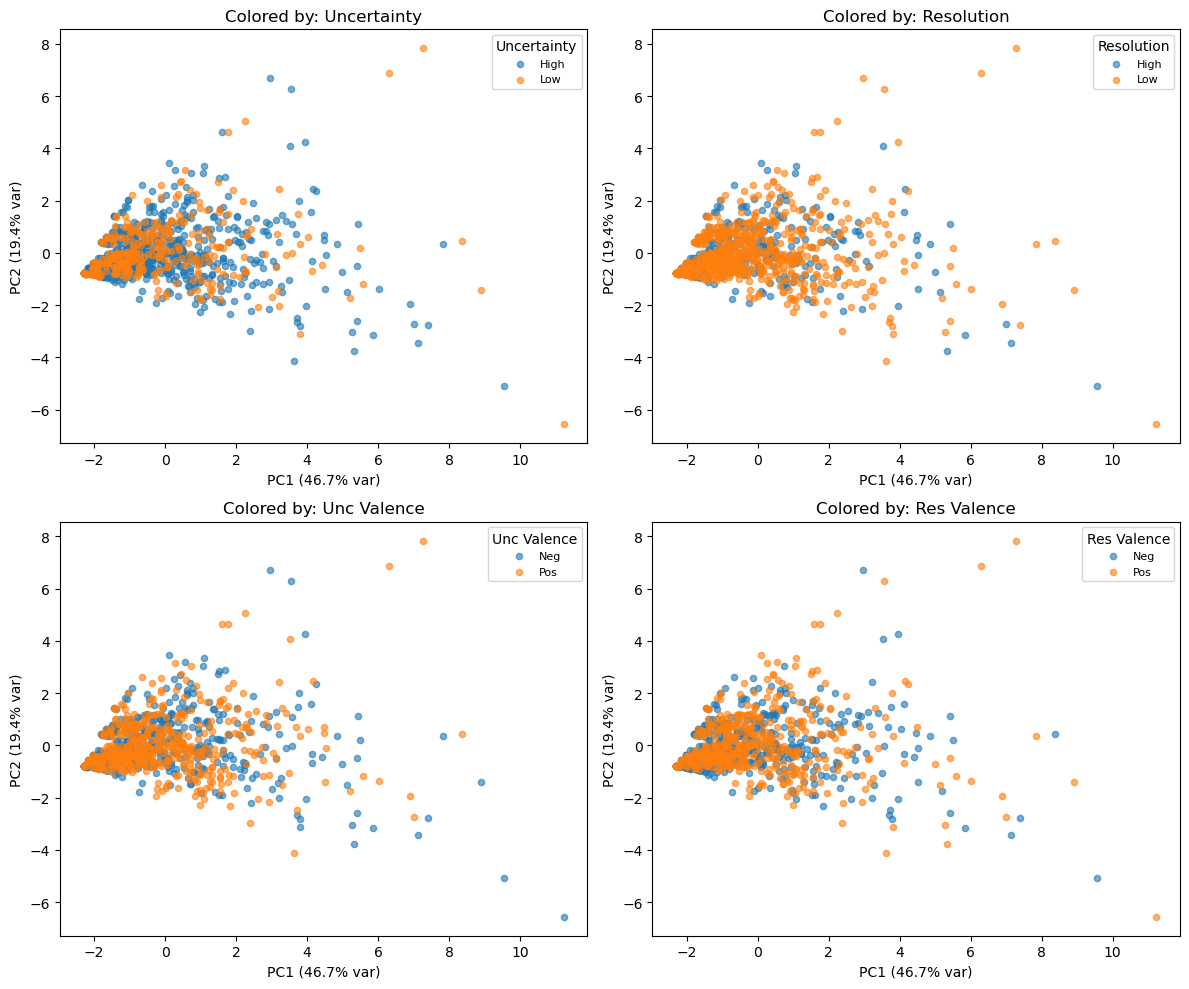

In [208]:
plot_df = df_clean[ALL_ID_COLS].copy()
plot_df["PC1"] = X_pca[:, 0]
plot_df["PC2"] = X_pca[:, 1]
 
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
 
for ax, cond_col in zip(axes, CONDITION_COLS):
    for level, sub in plot_df.groupby(cond_col):
        ax.scatter(sub["PC1"], sub["PC2"], label=str(level), alpha=0.6, s=20)
    ax.set_xlabel(f"PC1 ({explained_var[0]*100:.1f}% var)")
    ax.set_ylabel(f"PC2 ({explained_var[1]*100:.1f}% var)")
    ax.set_title(f"Colored by: {cond_col}")
    ax.legend(title=cond_col, fontsize=8)
 
plt.tight_layout()
plt.show()

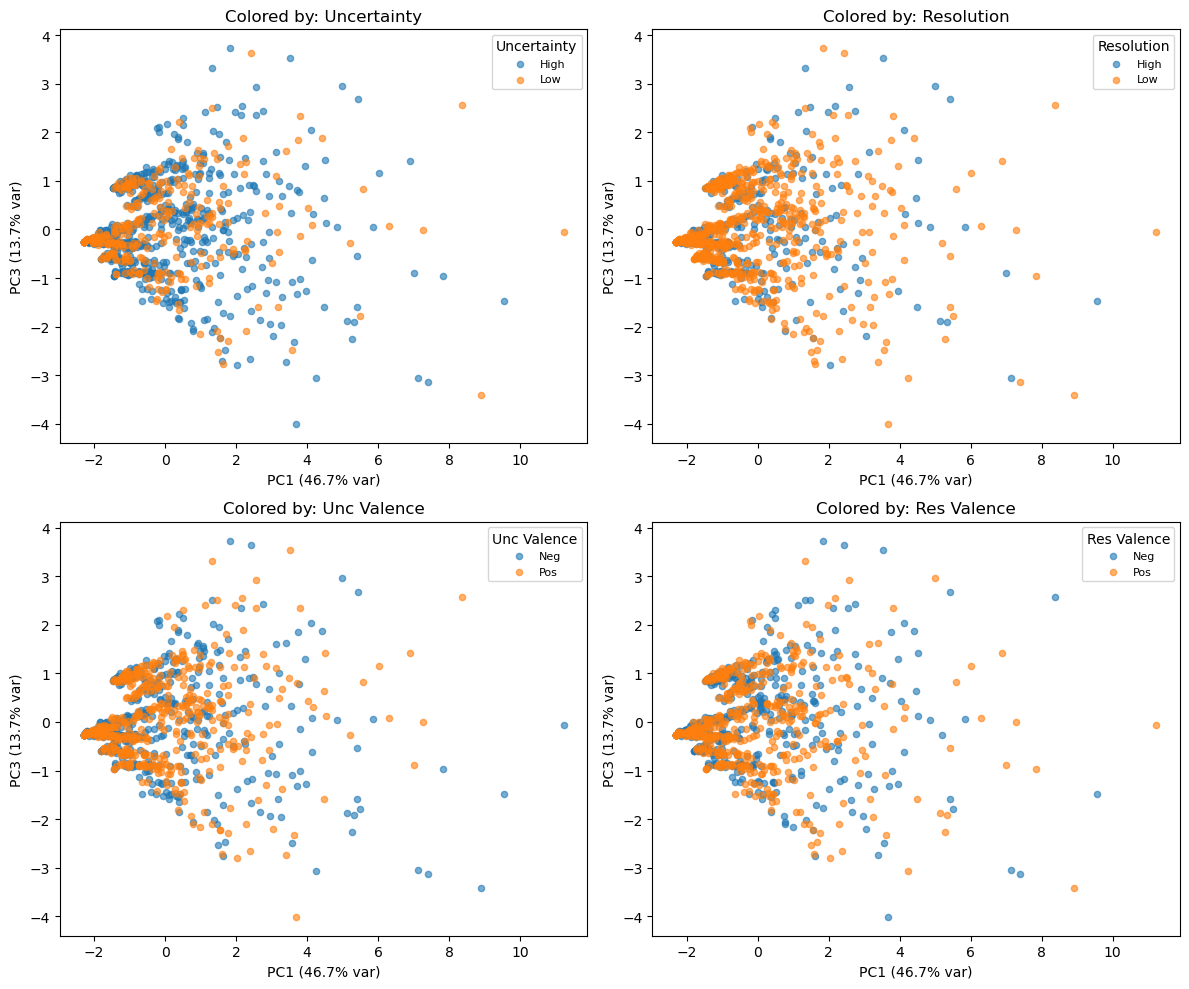

In [209]:
plot_df = df_clean[ALL_ID_COLS].copy()
plot_df["PC1"] = X_pca[:, 0]
plot_df["PC3"] = X_pca[:, 2]
 
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
 
for ax, cond_col in zip(axes, CONDITION_COLS):
    for level, sub in plot_df.groupby(cond_col):
        ax.scatter(sub["PC1"], sub["PC3"], label=str(level), alpha=0.6, s=20)
    ax.set_xlabel(f"PC1 ({explained_var[0]*100:.1f}% var)")
    ax.set_ylabel(f"PC3 ({explained_var[2]*100:.1f}% var)")
    ax.set_title(f"Colored by: {cond_col}")
    ax.legend(title=cond_col, fontsize=8)
 
plt.tight_layout()
plt.show()

In [210]:
# n_missing = plot_df[["Uncertainty", "Resolution", "Unc Valence", "Res Valence"]].isna().any(axis=1).sum()
# # print(f"Missing rows: {n_missing}")
# plot_df = plot_df.dropna(subset=["Uncertainty", "Resolution", "Unc Valence", "Res Valence"]).reset_index(drop=True)

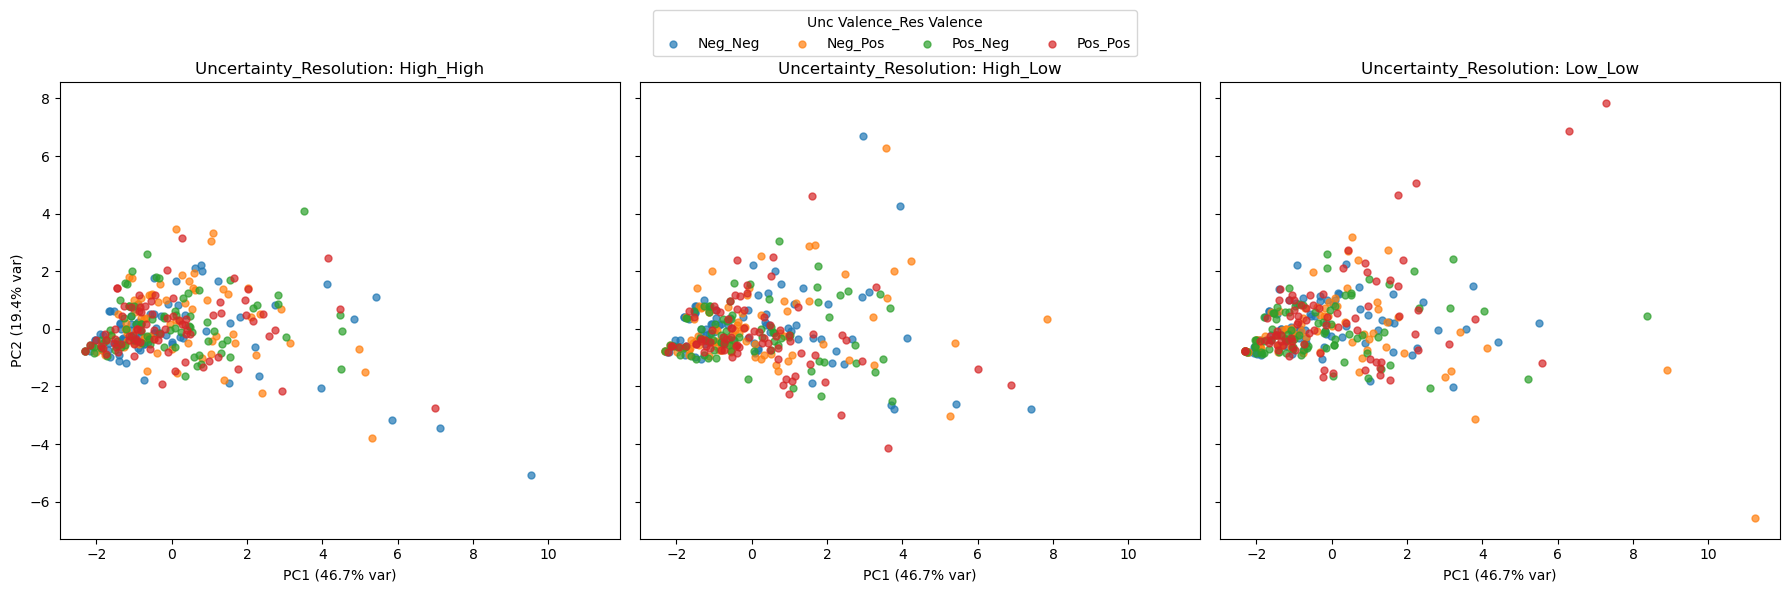

In [211]:
plot_df["PC1"] = X_pca[:, 0]
plot_df["PC2"] = X_pca[:, 1]
plot_df["PC3"] = X_pca[:, 2]
 
# Check for missing values in the condition columns
n_missing = plot_df[CONDITION_COLS].isna().any(axis=1).sum()
if n_missing > 0:
    print(f"Warning: dropping {n_missing} rows with missing condition values")
    plot_df = plot_df.dropna(subset=CONDITION_COLS).reset_index(drop=True)
 
plot_df["UR_combo"] = (
    plot_df["Uncertainty"].astype(str) + "_" + plot_df["Resolution"].astype(str)
)
plot_df["Valence_combo"] = (
    plot_df["Unc Valence"].astype(str) + "_" + plot_df["Res Valence"].astype(str)
)
 
ur_levels = sorted(plot_df["UR_combo"].unique())          # panels
valence_levels = sorted(plot_df["Valence_combo"].unique())  # colors
 
# Fixed color per valence combo, shared across all panels
cmap = plt.get_cmap("tab10")
color_map = {lvl: cmap(i) for i, lvl in enumerate(valence_levels)}
 
n_panels = len(ur_levels)
fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 5.5), sharex=True, sharey=True)
if n_panels == 1:
    axes = [axes]
 
for ax, ur in zip(axes, ur_levels):
    sub_panel = plot_df[plot_df["UR_combo"] == ur]
    for val_combo in valence_levels:
        sub = sub_panel[sub_panel["Valence_combo"] == val_combo]
        if len(sub) == 0:
            continue
        ax.scatter(
            sub["PC1"], sub["PC2"],
            label=val_combo, color=color_map[val_combo],
            alpha=0.7, s=25,
        )
    ax.set_xlabel(f"PC1 ({explained_var[0]*100:.1f}% var)")
    ax.set_title(f"Uncertainty_Resolution: {ur}")
 
axes[0].set_ylabel(f"PC2 ({explained_var[1]*100:.1f}% var)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Unc Valence_Res Valence",
           loc="upper center", ncol=len(valence_levels), bbox_to_anchor=(0.5, 1.08))
plt.tight_layout()
plt.show()

# k-means clustering

In [212]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

c:\Users\blanc\anaconda3\envs\internship\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\blanc\anaconda3\envs\internship\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


k=2: silhouette score = 0.395
k=3: silhouette score = 0.293


c:\Users\blanc\anaconda3\envs\internship\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\blanc\anaconda3\envs\internship\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


k=4: silhouette score = 0.290
k=5: silhouette score = 0.218


c:\Users\blanc\anaconda3\envs\internship\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\blanc\anaconda3\envs\internship\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


k=6: silhouette score = 0.215
k=7: silhouette score = 0.222

Best k by silhouette score: 2


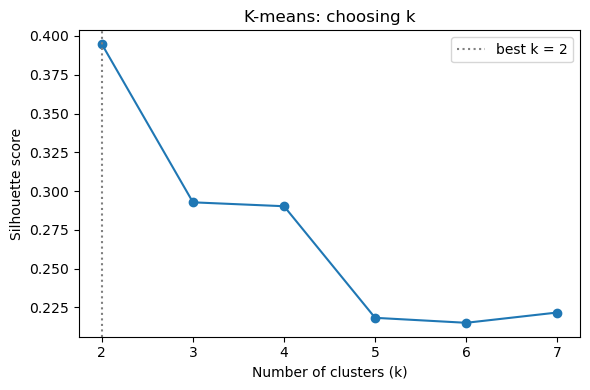

In [213]:
k_range = range(2, 8)
sil_scores = []
 
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f"k={k}: silhouette score = {score:.3f}")
 
best_k = list(k_range)[int(np.argmax(sil_scores))]
print(f"\nBest k by silhouette score: {best_k}")
 
plt.figure(figsize=(6, 4))
plt.plot(list(k_range), sil_scores, "o-")
plt.axvline(best_k, color="gray", linestyle=":", label=f"best k = {best_k}")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("K-means: choosing k")
plt.legend()
plt.tight_layout()
plt.show()

In [214]:
import os
os.environ["OMP_NUM_THREADS"] = "4"

kmeans_final = KMeans(n_clusters=best_k, n_init=10, random_state=42)
cluster_labels = kmeans_final.fit_predict(X_scaled)
 
df_clean["kmeans_cluster"] = cluster_labels
plot_df["kmeans_cluster"] = cluster_labels[: len(plot_df)] if len(plot_df) == len(df_clean) else np.nan
 
# --- 10c. Compare clusters to each condition factor via ARI ---
print("\nAdjusted Rand Index (cluster assignment vs. condition factor):")
ari_results = {}
for col in CONDITION_COLS:
    ari = adjusted_rand_score(df_clean[col].astype(str), cluster_labels)
    ari_results[col] = ari
    print(f"  {col}: ARI = {ari:.3f}")
 
# Also check the combined UR and Valence groupings, if present
if "UR_combo" not in df_clean.columns:
    df_clean["UR_combo"] = (
        df_clean["Uncertainty"].astype(str) + "_" + df_clean["Resolution"].astype(str)
    )
if "Valence_combo" not in df_clean.columns:
    df_clean["Valence_combo"] = (
        df_clean["Unc Valence"].astype(str) + "_" + df_clean["Res Valence"].astype(str)
    )
 
ari_ur = adjusted_rand_score(df_clean["UR_combo"], cluster_labels)
ari_valence = adjusted_rand_score(df_clean["Valence_combo"], cluster_labels)
print(f"  UR_combo: ARI = {ari_ur:.3f}")
print(f"  Valence_combo: ARI = {ari_valence:.3f}")


Adjusted Rand Index (cluster assignment vs. condition factor):
  Uncertainty: ARI = -0.003
  Resolution: ARI = -0.007
  Unc Valence: ARI = -0.001
  Res Valence: ARI = -0.000
  UR_combo: ARI = -0.000
  Valence_combo: ARI = -0.001


c:\Users\blanc\anaconda3\envs\internship\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


  participant: ARI = 0.020  (high value here suggests clusters mostly track individual differences, not condition)


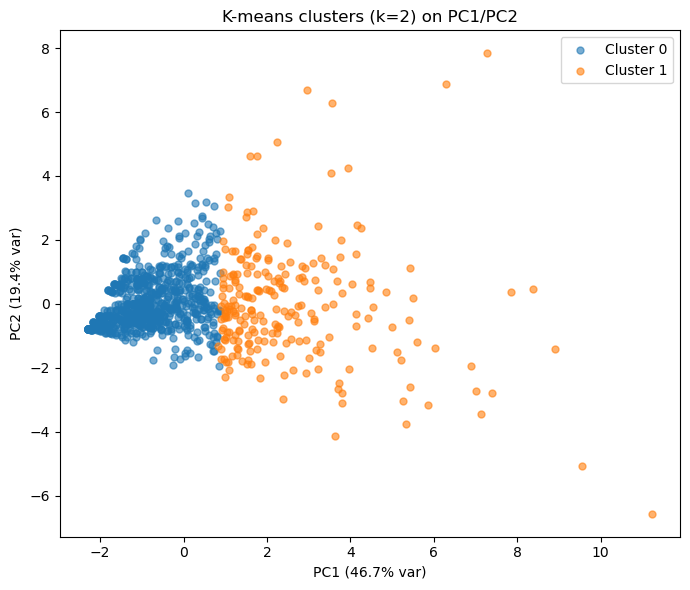

In [215]:
ari_participant = adjusted_rand_score(df_clean["participant"].astype(str), cluster_labels)
print(f"  participant: ARI = {ari_participant:.3f}  (high value here suggests "
      f"clusters mostly track individual differences, not condition)")
 
# --- 10e. Visualize clusters on PC1/PC2 ---
plt.figure(figsize=(7, 6))
for c in sorted(set(cluster_labels)):
    mask = cluster_labels == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f"Cluster {c}", alpha=0.6, s=25)
plt.xlabel(f"PC1 ({explained_var[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({explained_var[1]*100:.1f}% var)")
plt.title(f"K-means clusters (k={best_k}) on PC1/PC2")
plt.legend()
plt.tight_layout()
plt.show()
 
# --- 10f. Save cluster assignments alongside condition labels ---
cluster_out = df_clean[ID_COLS + CONDITION_COLS + ["kmeans_cluster"]].copy()
# cluster_out.to_csv("kmeans_cluster_assignments.csv", index=False)
 

In [216]:
print("\n--- Cluster membership by condition (counts) ---")
for col in CONDITION_COLS:
    print(f"\n{col}:")
    ct = pd.crosstab(cluster_out[col], cluster_out["kmeans_cluster"])
    print(ct)
 
# Same, but as row-wise percentages -- easier to spot enrichment,
# since raw counts can be misleading if clusters are unequal in size.
print("\n--- Cluster membership by condition (row %) ---")
for col in CONDITION_COLS:
    print(f"\n{col}:")
    ct_pct = pd.crosstab(cluster_out[col], cluster_out["kmeans_cluster"], normalize="index") * 100
    print(ct_pct.round(1))
 
# Combined UR x Valence breakdown, if you want the full 4-way picture
cluster_out["UR_combo"] = (
    cluster_out["Uncertainty"].astype(str) + "_" + cluster_out["Resolution"].astype(str)
)
cluster_out["Valence_combo"] = (
    cluster_out["Unc Valence"].astype(str) + "_" + cluster_out["Res Valence"].astype(str)
)
 
print("\n--- Cluster membership by UR_combo x Valence_combo (counts) ---")
ct_full = pd.crosstab(
    [cluster_out["UR_combo"], cluster_out["Valence_combo"]],
    cluster_out["kmeans_cluster"],
)
print(ct_full)
 
# ct_full.to_csv("cluster_by_condition_crosstab.csv")
# print("\nSaved: cluster_by_condition_crosstab.csv")


--- Cluster membership by condition (counts) ---

Uncertainty:
kmeans_cluster    0    1
Uncertainty             
High            485  155
Low             245   75

Resolution:
kmeans_cluster    0    1
Resolution              
High            248   72
Low             482  158

Unc Valence:


kmeans_cluster    0    1
Unc Valence             
Neg             367  113
Pos             363  117

Res Valence:
kmeans_cluster    0    1
Res Valence             
Neg             371  109
Pos             359  121

--- Cluster membership by condition (row %) ---

Uncertainty:
kmeans_cluster     0     1
Uncertainty               
High            75.8  24.2
Low             76.6  23.4

Resolution:
kmeans_cluster     0     1
Resolution                
High            77.5  22.5
Low             75.3  24.7

Unc Valence:
kmeans_cluster     0     1
Unc Valence               
Neg             76.5  23.5
Pos             75.6  24.4

Res Valence:
kmeans_cluster     0     1
Res Valence               
Neg             77.3  22.7
Pos             74.8  25.2

--- Cluster membership by UR_combo x Valence_combo (counts) ---
kmeans_cluster            0   1
UR_combo  Valence_combo        
High_High Neg_Neg        65  15
          Neg_Pos        59  21
          Pos_Neg        63  17
          Pos_Pos        

In [217]:

# --- 12a. Stacked bar chart per condition factor (counts) ---
fig, axes = plt.subplots(1, len(CONDITION_COLS), figsize=(5 * len(CONDITION_COLS), 5))
if len(CONDITION_COLS) == 1:
    axes = [axes]
 
cluster_ids_sorted = sorted(cluster_out["kmeans_cluster"].unique())
cmap = plt.get_cmap("tab10")
cluster_colors = {c: cmap(i) for i, c in enumerate(cluster_ids_sorted)}
 
for ax, col in zip(axes, CONDITION_COLS):
    ct = pd.crosstab(cluster_out[col], cluster_out["kmeans_cluster"])
    ct = ct[cluster_ids_sorted]  # consistent cluster order/colors across panels
    bottom = np.zeros(len(ct))
    for c in cluster_ids_sorted:
        ax.bar(ct.index.astype(str), ct[c], bottom=bottom,
               label=f"Cluster {c}", color=cluster_colors[c])
        bottom += ct[c].values
    ax.set_title(col)
    ax.set_ylabel("Number of trials")
    ax.tick_params(axis="x", rotation=45)
 
axes[0].legend(title="Cluster")
plt.tight_layout()
plt.savefig("cluster_by_condition_stacked_bars.png", dpi=150)
plt.close()
 
# --- 12b. Same, but as row percentages (better for spotting enrichment
#     when cluster sizes are very unequal) ---
fig, axes = plt.subplots(1, len(CONDITION_COLS), figsize=(5 * len(CONDITION_COLS), 5))
if len(CONDITION_COLS) == 1:
    axes = [axes]
 
for ax, col in zip(axes, CONDITION_COLS):
    ct_pct = pd.crosstab(cluster_out[col], cluster_out["kmeans_cluster"], normalize="index") * 100
    ct_pct = ct_pct[cluster_ids_sorted]
    bottom = np.zeros(len(ct_pct))
    for c in cluster_ids_sorted:
        ax.bar(ct_pct.index.astype(str), ct_pct[c], bottom=bottom,
               label=f"Cluster {c}", color=cluster_colors[c])
        bottom += ct_pct[c].values
    ax.set_title(col)
    ax.set_ylabel("% of trials")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=45)
 
axes[0].legend(title="Cluster")
plt.tight_layout()
plt.savefig("cluster_by_condition_stacked_bars_pct.png", dpi=150)
plt.close()
 
# --- 12c. Heatmap of the full UR_combo x Valence_combo breakdown ---
plt.figure(figsize=(1.5 * len(cluster_ids_sorted) + 3, 0.4 * len(ct_full) + 2))
plt.imshow(ct_full.values, aspect="auto", cmap="Blues")
plt.colorbar(label="Number of trials")
plt.xticks(range(len(ct_full.columns)), [f"Cluster {c}" for c in ct_full.columns])
plt.yticks(range(len(ct_full.index)), [" | ".join(idx) for idx in ct_full.index])
for i in range(ct_full.shape[0]):
    for j in range(ct_full.shape[1]):
        plt.text(j, i, str(ct_full.values[i, j]), ha="center", va="center", fontsize=8)
plt.title("Cluster membership by UR_combo x Valence_combo")
plt.tight_layout()
plt.savefig("cluster_by_condition_heatmap.png", dpi=150)
plt.close()
 
print("Saved: cluster_by_condition_stacked_bars.png, "
      "cluster_by_condition_stacked_bars_pct.png, cluster_by_condition_heatmap.png")

Saved: cluster_by_condition_stacked_bars.png, cluster_by_condition_stacked_bars_pct.png, cluster_by_condition_heatmap.png


# supervised machine learning

In [ ]:
from sklearn.model_selection import GroupKFold, cross_val_score, permutation_test_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
 
groups = df_clean["participant"].values
n_groups = len(np.unique(groups))
n_splits = min(5, n_groups)  # can't have more folds than participants
 
group_kfold = GroupKFold(n_splits=n_splits)
 
print(f"\nCross-validated decoding (GroupKFold, {n_splits} folds, "
      f"held-out by participant):\n")
 
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
}
 
decoding_results = []
null_distributions = {}  # (cond_col, clf_name) -> perm_scores array, for plotting
 
for cond_col in CONDITION_COLS + ["UR_combo", "Valence_combo"]:
    if cond_col in ["UR_combo", "Valence_combo"]:
        y = df_clean[cond_col].values if cond_col in df_clean.columns else None
        if y is None:
            continue
    else:
        y = df_clean[cond_col].astype(str).values
 
    n_classes = len(np.unique(y))
    # TRUE chance level = majority-class baseline, not 1/n_classes.
    # With an imbalanced design (e.g. only 3 of 4 possible UR cells exist),
    # "always predict the majority class" can easily beat 1/n_classes
    # without any real decoding happening -- this is what caused the
    # Uncertainty/Resolution accuracies to land suspiciously exactly on
    # 0.667 instead of near the naive 0.5 "chance" we printed before.
    class_counts = pd.Series(y).value_counts()
    chance_level = class_counts.max() / len(y)
 
    print(f"--- {cond_col} ({n_classes} classes, majority-class chance = {chance_level:.3f}) ---")
 
    for clf_name, clf in classifiers.items():
        scores = cross_val_score(clf, X_scaled, y, cv=group_kfold, groups=groups, scoring="accuracy")
        mean_acc = scores.mean()
 
        # Permutation test: shuffle labels many times, see how often we'd
        # get an accuracy this high by chance. Gives a proper p-value
        # instead of just eyeballing "is it above chance level."
        _, perm_scores, p_value = permutation_test_score(
            clf, X_scaled, y, cv=group_kfold, groups=groups,
            scoring="accuracy", n_permutations=100, random_state=42, n_jobs=-1,
        )
        null_distributions[(cond_col, clf_name)] = perm_scores
 
        print(f"  {clf_name}: accuracy = {mean_acc:.3f} (+/- {scores.std():.3f}), "
              f"chance = {chance_level:.3f}, permutation p = {p_value:.3f}")
 
        decoding_results.append({
            "condition": cond_col, "classifier": clf_name,
            "accuracy": mean_acc, "accuracy_std": scores.std(),
            "chance_level": chance_level, "n_classes": n_classes,
            "p_value": p_value,
        })
    print()
 
decoding_df = pd.DataFrame(decoding_results)
 
# --- Benjamini-Hochberg correction for multiple comparisons ---
# You ran 6 conditions x 2 classifiers = 12 tests. At uncorrected alpha=0.05
# you'd expect ~0.6 false positives just by chance, so raw p-values alone
# overstate significance -- BH gives a defensible corrected answer.
def benjamini_hochberg(pvals, alpha=0.05):
    pvals = np.asarray(pvals)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    thresholds = (np.arange(1, n + 1) / n) * alpha
    passed = ranked <= thresholds
    # largest rank where p <= threshold -> that and everything below it passes
    if passed.any():
        max_rank = np.max(np.where(passed)[0])
        cutoff = ranked[max_rank]
    else:
        cutoff = 0.0
    significant = pvals <= cutoff
    # q-values (BH-adjusted): running min from the largest p-value down
    q = np.empty(n)
    q[order] = ranked * n / np.arange(1, n + 1)
    q_sorted_desc = np.minimum.accumulate(q[order][::-1])[::-1]
    q[order] = np.clip(q_sorted_desc, 0, 1)
    return significant, q
 
sig_bh, q_values = benjamini_hochberg(decoding_df["p_value"].values, alpha=0.05)
decoding_df["q_value_BH"] = q_values
decoding_df["significant_BH"] = sig_bh
decoding_df["significant_raw"] = decoding_df["p_value"] < 0.05
 
decoding_df.to_csv("classifier_decoding_results.csv", index=False)
print("Saved: classifier_decoding_results.csv")
print("\nResults with multiple-comparison correction:")
print(decoding_df[["condition", "classifier", "accuracy", "chance_level",
                    "p_value", "q_value_BH", "significant_BH"]].round(3).to_string(index=False))
 
# ---------------------------------------------------------------------
# 13b. Three report-ready plots instead of one crowded bar chart
# ---------------------------------------------------------------------
conditions_order = list(decoding_df["condition"].unique())
clf_names = list(classifiers.keys())
clf_colors = {"Logistic Regression": "#4C72B0", "Random Forest": "#DD8452"}
 
def sig_marker(row):
    if row["significant_BH"]:
        return "**"      # survives multiple-comparison correction
    elif row["significant_raw"]:
        return "*"       # nominal p<0.05 only, doesn't survive correction
    else:
        return ""
 
decoding_df["sig_marker"] = decoding_df.apply(sig_marker, axis=1)
 
# --- Plot 1: accuracy vs. TRUE (majority-class) chance, per condition,
#     with significance markers and correct per-condition chance lines ---
fig, ax = plt.subplots(figsize=(11, 6))
x_pos = np.arange(len(conditions_order))
width = 0.35
 
for i, clf_name in enumerate(clf_names):
    sub = decoding_df[decoding_df["classifier"] == clf_name].set_index("condition")
    accs = [sub.loc[c, "accuracy"] for c in conditions_order]
    stds = [sub.loc[c, "accuracy_std"] for c in conditions_order]
    bars = ax.bar(x_pos + i * width, accs, width, yerr=stds, capsize=3,
                   label=clf_name, color=clf_colors[clf_name])
    for j, c in enumerate(conditions_order):
        marker = sub.loc[c, "sig_marker"]
        if marker:
            ax.text(x_pos[j] + i * width, accs[j] + stds[j] + 0.01, marker,
                    ha="center", fontsize=13, fontweight="bold")
 
# Per-condition chance level as a short horizontal tick, not one shared line
# (chance differs by condition since class balance differs)
for j, c in enumerate(conditions_order):
    cl = decoding_df[decoding_df["condition"] == c]["chance_level"].iloc[0]
    ax.plot([x_pos[j] - width * 0.6, x_pos[j] + width * 1.6], [cl, cl],
             "k--", linewidth=1.3,
             label="Majority-class chance" if j == 0 else None)
 
ax.set_xticks(x_pos + width / 2)
ax.set_xticklabels(conditions_order, rotation=25, ha="right")
ax.set_ylabel("Cross-validated accuracy")
ax.set_title("Decoding accuracy vs. true chance (GroupKFold by participant)\n"
             "* p<0.05 uncorrected   ** significant after BH correction")
ax.legend()
plt.tight_layout()
plt.savefig("classifier_accuracy_vs_chance.png", dpi=150)
plt.close()
 
# --- Plot 2: accuracy ABOVE chance (the number that actually matters for
#     "is there a real effect", removes the visual distraction of bars
#     that are mostly just showing class imbalance) ---
fig, ax = plt.subplots(figsize=(11, 6))
for i, clf_name in enumerate(clf_names):
    sub = decoding_df[decoding_df["classifier"] == clf_name].set_index("condition")
    diffs = [sub.loc[c, "accuracy"] - sub.loc[c, "chance_level"] for c in conditions_order]
    stds = [sub.loc[c, "accuracy_std"] for c in conditions_order]
    bars = ax.bar(x_pos + i * width, diffs, width, yerr=stds, capsize=3,
                   label=clf_name, color=clf_colors[clf_name])
    for j, c in enumerate(conditions_order):
        marker = sub.loc[c, "sig_marker"]
        if marker:
            y_text = diffs[j] + stds[j] + 0.005 if diffs[j] >= 0 else diffs[j] - stds[j] - 0.015
            ax.text(x_pos[j] + i * width, y_text, marker, ha="center", fontsize=13, fontweight="bold")
 
ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(x_pos + width / 2)
ax.set_xticklabels(conditions_order, rotation=25, ha="right")
ax.set_ylabel("Accuracy minus chance level")
ax.set_title("Decoding improvement over chance\n"
             "* p<0.05 uncorrected   ** significant after BH correction")
ax.legend()
plt.tight_layout()
plt.savefig("classifier_accuracy_above_chance.png", dpi=150)
plt.close()
 
# --- Plot 3: permutation null distributions for the two most interesting
#     conditions (lowest raw p-values), so you can visually show WHY a
#     result is/isn't significant rather than just citing a p-value ---
top_conditions = (decoding_df.sort_values("p_value")
                   .drop_duplicates(subset=["condition", "classifier"])
                   .head(4))
 
fig, axes = plt.subplots(1, len(top_conditions), figsize=(5 * len(top_conditions), 4.5))
if len(top_conditions) == 1:
    axes = [axes]
 
for ax, (_, row) in zip(axes, top_conditions.iterrows()):
    perm_scores = null_distributions[(row["condition"], row["classifier"])]
    ax.hist(perm_scores, bins=20, color="lightgray", edgecolor="white")
    ax.axvline(row["accuracy"], color="crimson", linewidth=2,
                label=f"Real accuracy = {row['accuracy']:.3f}")
    ax.axvline(row["chance_level"], color="black", linestyle="--", linewidth=1,
                label=f"Chance = {row['chance_level']:.3f}")
    ax.set_title(f"{row['condition']} ({row['classifier']})\np = {row['p_value']:.3f}", fontsize=10)
    ax.set_xlabel("Accuracy under shuffled labels")
    ax.legend(fontsize=8)
 
axes[0].set_ylabel("Number of permutations")
plt.tight_layout()
plt.savefig("classifier_permutation_null_distributions.png", dpi=150)
plt.close()
 
print("Saved: classifier_accuracy_vs_chance.png, classifier_accuracy_above_chance.png, "
      "classifier_permutation_null_distributions.png")


Cross-validated decoding (GroupKFold, 5 folds, held-out by participant):

--- Uncertainty (2 classes, majority-class chance = 0.667) ---
  Logistic Regression: accuracy = 0.667 (+/- 0.000), chance = 0.667, permutation p = 0.366
  Random Forest: accuracy = 0.601 (+/- 0.024), chance = 0.667, permutation p = 0.446

--- Resolution (2 classes, majority-class chance = 0.667) ---
  Logistic Regression: accuracy = 0.666 (+/- 0.004), chance = 0.667, permutation p = 0.406


# logistic regression

In [ ]:
# ---------------------------------------------------------------------
# 14. Single multinomial LR predicting the full joint condition
# ---------------------------------------------------------------------
from sklearn.model_selection import cross_val_predict

y_full = df_clean[CONDITION_COLS].astype(str).agg("_".join, axis=1).values
n_classes_full = len(np.unique(y_full))
chance_full = pd.Series(y_full).value_counts().max() / len(y_full)

clf_full = LogisticRegression(max_iter=1000, random_state=42)

scores_full = cross_val_score(clf_full, X_scaled, y_full, cv=group_kfold,
                               groups=groups, scoring="accuracy")
_, perm_scores_full, p_full = permutation_test_score(
    clf_full, X_scaled, y_full, cv=group_kfold, groups=groups,
    scoring="accuracy", n_permutations=100, random_state=42, n_jobs=-1,
)

print(f"Joint condition ({n_classes_full} classes, chance = {chance_full:.3f}): "
      f"accuracy = {scores_full.mean():.3f} (+/- {scores_full.std():.3f}), p = {p_full:.3f}")

# Out-of-fold predictions from THIS SAME model -> split back into factors
# to get marginal accuracies (descriptive, not separate hypothesis tests,
# since they all come from one fitted classifier).
y_pred_full = cross_val_predict(clf_full, X_scaled, y_full, cv=group_kfold, groups=groups)

pred_factors = pd.DataFrame(
    [p.split("_") for p in y_pred_full], columns=CONDITION_COLS
)
true_factors = df_clean[CONDITION_COLS].astype(str).reset_index(drop=True)

for col in CONDITION_COLS:
    acc = (pred_factors[col].values == true_factors[col].values).mean()
    print(f"  marginal accuracy for {col} (from joint model): {acc:.3f}")

Joint condition (12 classes, chance = 0.083): accuracy = 0.095 (+/- 0.016), p = 0.099
  marginal accuracy for Uncertainty (from joint model): 0.556
  marginal accuracy for Resolution (from joint model): 0.597
  marginal accuracy for Unc Valence (from joint model): 0.522
  marginal accuracy for Res Valence (from joint model): 0.493


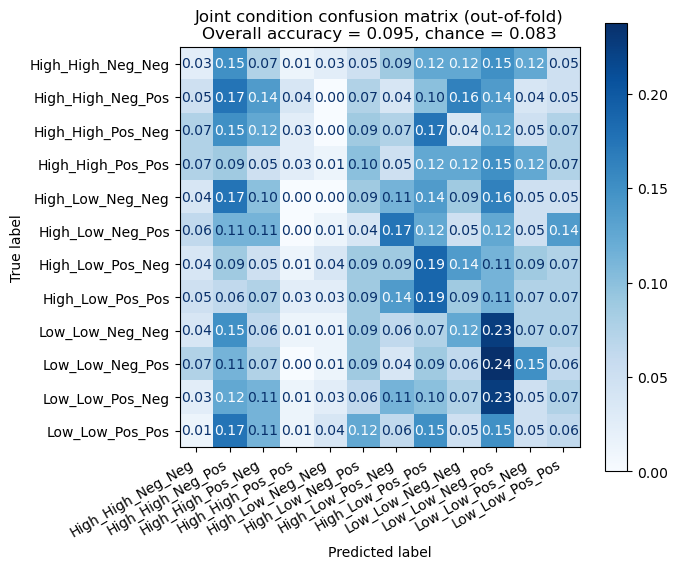

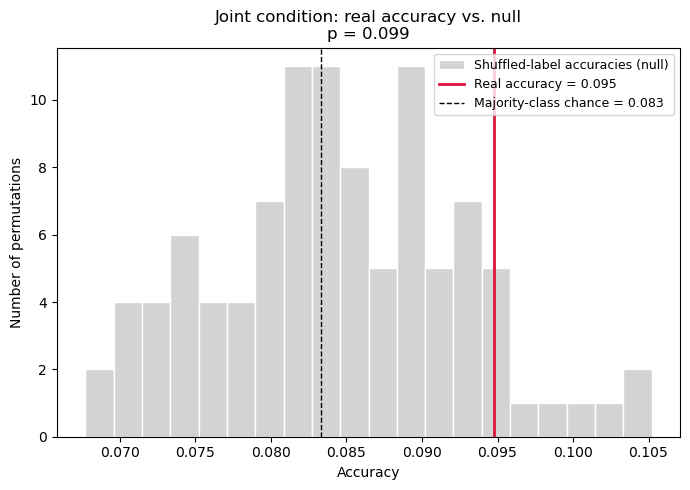

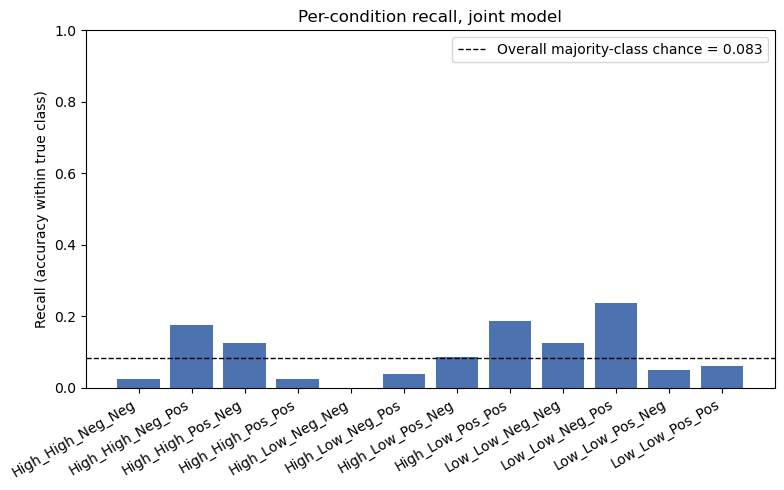

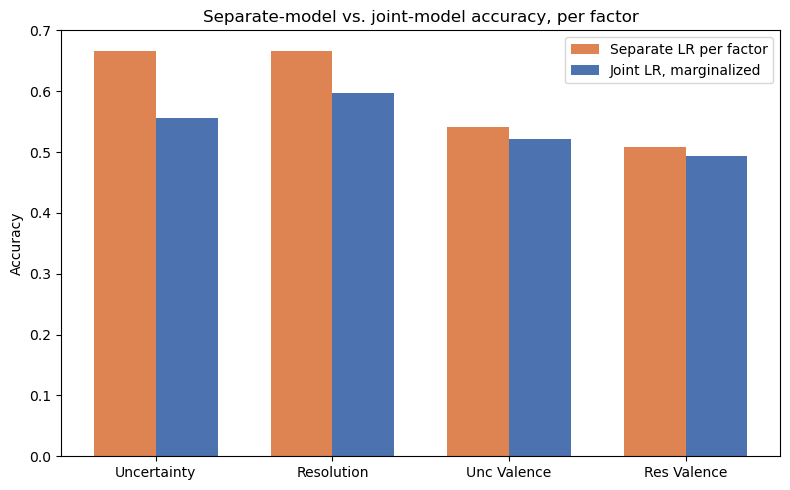

In [ ]:
# ---------------------------------------------------------------------
# 14b. Diagnostic plots for the joint-condition model
# ---------------------------------------------------------------------
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_labels = sorted(np.unique(y_full))

# --- Plot 1: confusion matrix (out-of-fold predictions, so it's honest
#     about generalization, not just fit on training data) ---
cm = confusion_matrix(true_factors.agg("_".join, axis=1).values, y_pred_full,
                       labels=class_labels, normalize="true")

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=True)
ax.set_title(f"Joint condition confusion matrix (out-of-fold)\n"
             f"Overall accuracy = {scores_full.mean():.3f}, chance = {chance_full:.3f}")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# --- Plot 2: real accuracy vs. permutation null distribution ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(perm_scores_full, bins=20, color="lightgray", edgecolor="white",
        label="Shuffled-label accuracies (null)")
ax.axvline(scores_full.mean(), color="crimson", linewidth=2,
           label=f"Real accuracy = {scores_full.mean():.3f}")
ax.axvline(chance_full, color="black", linestyle="--", linewidth=1,
           label=f"Majority-class chance = {chance_full:.3f}")
ax.set_xlabel("Accuracy")
ax.set_ylabel("Number of permutations")
ax.set_title(f"Joint condition: real accuracy vs. null\np = {p_full:.3f}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# --- Plot 3: per-class accuracy (diagonal of the confusion matrix),
#     so you can see if the model is only good at a few conditions ---
per_class_acc = np.diag(cm)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(class_labels, per_class_acc, color="#4C72B0")
ax.axhline(chance_full, color="black", linestyle="--", linewidth=1,
           label=f"Overall majority-class chance = {chance_full:.3f}")
ax.set_ylabel("Recall (accuracy within true class)")
ax.set_title("Per-condition recall, joint model")
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

# --- Plot 4: marginal accuracies derived from the joint model, next to
#     each factor's own single-factor model from your original loop,
#     so you can see whether predicting jointly helps or hurts each factor ---
marginal_accs = {
    col: (pred_factors[col].values == true_factors[col].values).mean()
    for col in CONDITION_COLS
}
single_factor_accs = {
    col: decoding_df[(decoding_df["condition"] == col) &
                      (decoding_df["classifier"] == "Logistic Regression")]["accuracy"].values[0]
    for col in CONDITION_COLS
}

fig, ax = plt.subplots(figsize=(8, 5))
x_pos2 = np.arange(len(CONDITION_COLS))
w = 0.35
ax.bar(x_pos2 - w/2, [single_factor_accs[c] for c in CONDITION_COLS], w,
       label="Separate LR per factor", color="#DD8452")
ax.bar(x_pos2 + w/2, [marginal_accs[c] for c in CONDITION_COLS], w,
       label="Joint LR, marginalized", color="#4C72B0")
ax.set_xticks(x_pos2)
ax.set_xticklabels(CONDITION_COLS)
ax.set_ylabel("Accuracy")
ax.set_title("Separate-model vs. joint-model accuracy, per factor")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------------------
# 15. Explainability: LR coefficients + SHAP
# ---------------------------------------------------------------------
# Assumes `feature_cols` is the list of column names that were scaled into
# X_scaled, in the same order. If you don't have that variable saved,
# set it explicitly here, e.g.:
# feature_cols = ["feature_a", "feature_b", ...]

clf_full.fit(X_scaled, y_full)  # refit on all data for interpretation (not for reporting accuracy)

# --- Plot 1: LR coefficients, one panel per class (multinomial LR fits
#     one coefficient vector per class vs. the rest) ---
coefs = pd.DataFrame(clf_full.coef_, columns=FEATURE_COLS, index=clf_full.classes_)

n_classes_plot = len(clf_full.classes_)
fig, axes = plt.subplots(n_classes_plot, 1, figsize=(9, 3 * n_classes_plot), sharex=True)
if n_classes_plot == 1:
    axes = [axes]

for ax, cls in zip(axes, clf_full.classes_):
    row = coefs.loc[cls].sort_values()
    colors = ["#DD8452" if v < 0 else "#4C72B0" for v in row.values]
    ax.barh(row.index, row.values, color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"Class: {cls}")

axes[-1].set_xlabel("Coefficient (log-odds, standardized features)")
plt.tight_layout()
plt.show()

# --- Plot 2: overall importance ranking, averaged across classes
#     (mean absolute coefficient) ---
mean_abs_coef = coefs.abs().mean(axis=0).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, max(4, 0.3 * len(mean_abs_coef))))
ax.barh(mean_abs_coef.index[::-1], mean_abs_coef.values[::-1], color="#4C72B0")
ax.set_xlabel("Mean |coefficient| across classes")
ax.set_title("Overall feature importance, joint LR model")
plt.tight_layout()
plt.show()

NameError: name 'feature_cols' is not defined

In [ ]:
# --- SHAP: model-agnostic, works for LR and RF, gives per-prediction
#     explanations not just global coefficients ---
# pip install shap --break-system-packages   (if not already installed)
import shap

# For the linear model, shap.LinearExplainer is exact and fast
explainer_lr = shap.LinearExplainer(clf_full, X_scaled)
shap_values_lr = explainer_lr.shap_values(X_scaled)  # list of arrays, one per class

# Summary plot for one class of interest (edit which class you care about)
class_of_interest = clf_full.classes_[0]
class_idx = list(clf_full.classes_).index(class_of_interest)

shap.summary_plot(shap_values_lr[class_idx], X_scaled, feature_names=feature_cols,
                   show=False)
plt.title(f"SHAP summary — class: {class_of_interest}")
plt.tight_layout()
plt.show()

# --- Same for Random Forest, refit for interpretation ---
rf_full = RandomForestClassifier(n_estimators=200, random_state=42)
rf_full.fit(X_scaled, y_full)

explainer_rf = shap.TreeExplainer(rf_full)
shap_values_rf = explainer_rf.shap_values(X_scaled)

shap.summary_plot(shap_values_rf[class_idx], X_scaled, feature_names=feature_cols,
                   show=False)
plt.title(f"SHAP summary (Random Forest) — class: {class_of_interest}")
plt.tight_layout()
plt.show()

# --- Compare LR vs RF: do they agree on what matters? ---
mean_abs_shap_lr = np.abs(shap_values_lr[class_idx]).mean(axis=0)
mean_abs_shap_rf = np.abs(shap_values_rf[class_idx]).mean(axis=0)

comparison = pd.DataFrame({
    "feature": FEATURE_COLS,
    "LR_mean_|SHAP|": mean_abs_shap_lr,
    "RF_mean_|SHAP|": mean_abs_shap_rf,
}).sort_values("LR_mean_|SHAP|", ascending=False)

fig, ax = plt.subplots(figsize=(8, max(4, 0.3 * len(comparison))))
y_pos = np.arange(len(comparison))
ax.barh(y_pos - 0.2, comparison["LR_mean_|SHAP|"], 0.4, label="Logistic Regression", color="#4C72B0")
ax.barh(y_pos + 0.2, comparison["RF_mean_|SHAP|"], 0.4, label="Random Forest", color="#DD8452")
ax.set_yticks(y_pos)
ax.set_yticklabels(comparison["feature"])
ax.invert_yaxis()
ax.set_xlabel("Mean |SHAP value|")
ax.set_title(f"Feature importance comparison — class: {class_of_interest}")
ax.legend()
plt.tight_layout()
plt.show()

print(comparison.to_string(index=False))